# 单元7作业
    刘易昊 524021910055

## 作业目标
本单元作业围绕生物医学工程中的两个实际建模问题展开。请按规范流程完成：明确研究目的，读取数据，进行可视化，写出模型公式与假设条件，用 Python 建立线性模型，解释模型输出报告，评价模型质量，并给出面向工程或医学场景的解释。

请提交一份包含代码、图表、模型输出和文字解释的分析报告。每个小题的文字解释应避免只写“显著/不显著”，需要说明“系数代表什么”“模型可用于什么”“有什么限制”。

推荐使用：

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

#中文显示设置
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]  

## 综合题一：电化学乳酸传感器的标定模型（3 points）
模型用途：预测。

某生物医学工程团队正在开发用于运动监测和重症监护的电化学乳酸传感器。团队在 42 个校准样本中同时记录传感器电流响应和参考实验室乳酸浓度，希望建立一个简单线性模型，用传感器电流预测乳酸浓度。

变量说明：

- sample_id：校准样本编号
- sensor_current_uA：传感器输出电流，单位 uA
- reference_lactate_mmol_L：参考实验室乳酸浓度，单位 mmol/L

请完成以下问题：

### 1. 读取数据，查看数据维度、前 5 行、缺失值情况，并计算两个连续变量的描述性统计量。(0.2 points)

In [37]:
data1=pd.read_csv("unit7_problem1_lactate_sensor-1.csv")
print("数据维度:", data1.shape)
data1.info() 
data1.head(5)

数据维度: (42, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sample_id                 42 non-null     object 
 1   sensor_current_uA         42 non-null     float64
 2   reference_lactate_mmol_L  42 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.1+ KB


,sample_id,sensor_current_uA,reference_lactate_mmol_L
0,C01,5.4,0.55
1,C02,6.0,0.90
2,C03,6.7,1.73
3,C04,7.3,1.51
4,C05,7.9,2.19


从上面的结果来看，数据有42行、3列

通过对数据整体的分析，可以看到 `Non-Null Court` 列均为 `42 non-null` ，表明本数据无缺失值

同时也输出了本数据的前五行具体信息

In [38]:
print("传感器输出电流统计量：")
desc_stats_1 = data1["sensor_current_uA"].agg({
    "均值": "mean",
    "中位数": "median",
    "方差": "var",
    "标准差": "std"
})
display(desc_stats_1)

print("参考实验室乳酸浓度统计量：")
desc_stats_2 = data1["reference_lactate_mmol_L"].agg({
    "均值": "mean",
    "中位数": "median",
    "方差": "var",
    "标准差": "std"
})

display(desc_stats_2)

传感器输出电流统计量：


均值     18.285714
中位数    18.150000
方差     60.987596
标准差     7.809456
Name: sensor_current_uA, dtype: float64

参考实验室乳酸浓度统计量：


均值      6.335476
中位数     6.085000
方差     11.170060
标准差     3.342164
Name: reference_lactate_mmol_L, dtype: float64

### 2. 绘制 `sensor_current_uA` 与 `reference_lactate_mmol_L` 的散点图，并添加线性拟合线。根据图形初步判断是否适合使用简单线性模型。(0.4 points)

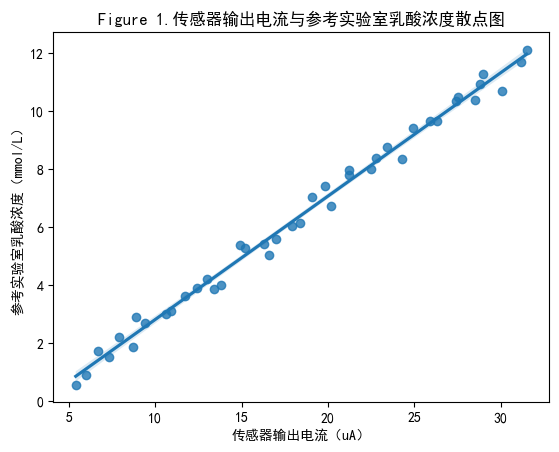

In [39]:
sns.regplot(x="sensor_current_uA", y="reference_lactate_mmol_L", data=data1,)
plt.xlabel("传感器输出电流（uA）")
plt.ylabel("参考实验室乳酸浓度（mmol/L）")
plt.title("Figure 1.传感器输出电流与参考实验室乳酸浓度散点图")
plt.show()

如 Figure 1 所示，散点围绕直线随机分布，且置信区间较窄，我们可以初步判断：

参考实验室乳酸浓度与传感器传出电流之间存在正相关的线性关系，可以使用简单线性模型来进行分析。且图中线性拟合线的置信区间较窄，同时也无明显异常值，两个变量之间的线性相关性较强。

### 3. 写出本题的简单线性回归模型公式，并逐条说明模型的主要假设条件：线性关系、误差独立性、误差均值为 0、同方差性、误差近似正态性。(0.4 points)

本题我们选择简单线性回归模型：
$$
Y=\beta_0+\beta_1 X+\varepsilon
$$

该模型的主要假设条件：

- 线性关系：因变量 $Y$ 与自变量 $X $之间存在真实的线性关系
- 误差独立性：任意两个不从观测的误差项之间不相关，$Cov(\varepsilon_i, \varepsilon_j)=0, i \neq j$
- 误差均值为0：对于每一个 $X$ 取值，误差项的期望为零，$E(\varepsilon_i|X_i)=0$。
- 同方差性：对于所有的 $X $取值，误差项的方差是常数，$ Var(\varepsilon_i|X_i)=\sigma^2 $
- 误差近似正态性：误差项服从正态分布， $ \varepsilon_i \sim N(0, \sigma^2) $

### 4. 使用 Python 的 statsmodels 建立模型：

`reference_lactate_mmol_L ~ sensor_current_uA`

输出完整模型报告。(0.4 points)

In [40]:
model_1 = smf.ols('reference_lactate_mmol_L ~ sensor_current_uA', data=data1)
results_1 = model_1.fit()
print(results_1.summary())

                               OLS Regression Results                               
Dep. Variable:     reference_lactate_mmol_L   R-squared:                       0.991
Model:                                  OLS   Adj. R-squared:                  0.991
Method:                       Least Squares   F-statistic:                     4568.
Date:                      Thu, 11 Jun 2026   Prob (F-statistic):           7.42e-43
Time:                              16:47:58   Log-Likelihood:                -10.086
No. Observations:                        42   AIC:                             24.17
Df Residuals:                            40   BIC:                             27.65
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

### 5.结合模型报告解释以下内容：截距、斜率、斜率的 95% 置信区间、斜率的 p 值、R-squared、Adj. R-squared、F-statistic、AIC/BIC。(0.4 points)

截距：-1.4561 $mmol/L$，即 $\beta_0$ 的估计值 $b_0$，自变量为0时因变量的均值

斜率：0.4261 $ \text{ mmol/(L}\cdot\mu\text{A)}$，即 $\beta_1$ 的估计值 $b_1$，自变量每增加一因变量的平均变化量

斜率的95%置信区间：[0.413, 0.439]，该区间不包含0，表明斜率显著大于0

斜率的 $p$ 值：0.000 < 0.05，拒绝原假设 $H_0: \beta_1 = 0$，认为斜率显著不等于0

R-Squared：0.991，$R^2 = \frac{SSR}{SST}$，$R^2$ 趋近于1，表明拟合效果较好

Adj. R-Squared：0.991，对于简单线性模型，$Adj. R^2$ 与 $R^2$ 大小相等，数值趋近1，表明模型简洁且解释力强

F-statistic：4568，用于检验整个回归模型是否显著的F统计量，其对应的p值为 $7.42\times 10^{-43} < 0.05$，表明模型整体极其显著

AIC：24.17，赤池信息量准则，用于模型评估，在多个模型之间对比

BIC：27.65，贝叶斯信息量准则，对参数惩罚略重于AIC

### 6. 绘制残差-拟合值图和 Q-Q 图，并可选用 Shapiro-Wilk 检验、Breusch-Pagan 检验辅助评价模型假设。说明模型假设是否基本可接受。(0.4 points)

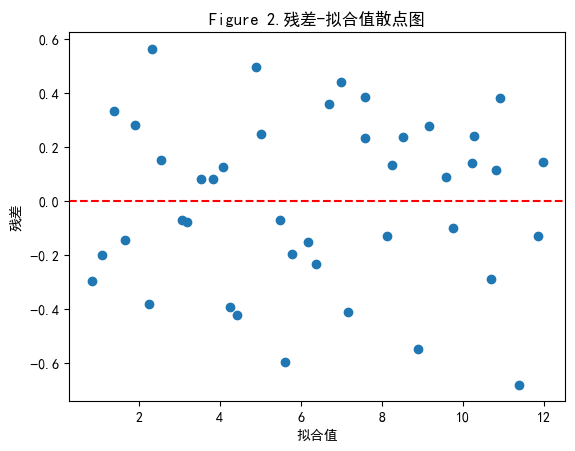

In [41]:
fitted_1 = results_1.fittedvalues
residuals_1 = results_1.resid

plt.scatter(fitted_1, residuals_1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("拟合值")
plt.ylabel("残差")
plt.title("Figure 2.残差-拟合值散点图")
plt.show()

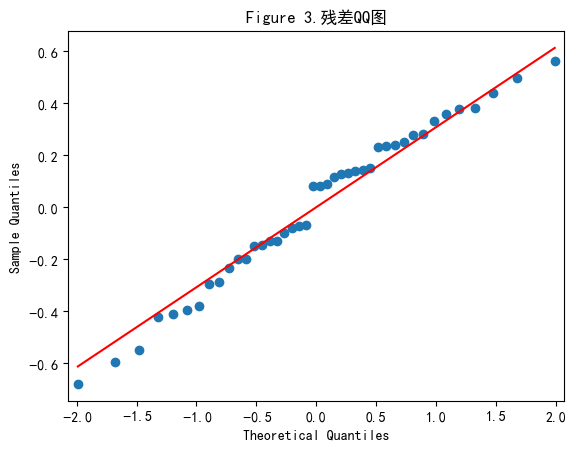

Shapiro-Wilk p-value: 0.4606
BP test p-value: 0.8007


In [42]:

sm.qqplot(residuals_1, line='s')
plt.title("Figure 3.残差QQ图")
plt.show()

# Shapiro-Wilk 检验
shapiro_stat, shapiro_p = stats.shapiro(residuals_1)
print(f'Shapiro-Wilk p-value: {shapiro_p:.4f}')

# Breusch-Pagan 检验
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals_1, results_1.model.exog)
print(f'BP test p-value: {bp_test[1]:.4f}')

如Figure 2所示，残差均匀分布在水平线 y=0上下，并且随着拟合值的增加，残差的离散程度保持恒定，没有出现漏斗形或喇叭形，同时也无明显异常值。

如Figure 3所示，残差的分布是基本符合正态分布的

同时进行了Shapiro-Wilk和Breusch-Pagan检验，结果分析如下：
- Shapiro-Wilk残差正态性检验 p=0.4606>0.05，不拒绝原假设，认为残差没有显著偏离正态分布
- Breusch-Pagan同方差性检验 p=0.8007>0.05，不拒绝原假设，认为残差方差恒定，不随拟合值变化而改变


### 7. 计算 RMSE 和 MAE，并解释它们在传感器标定场景中的含义。(0.4 points)



$$
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^n e_i^2}=\sqrt{\frac{SSE}{n}}
$$

用python程序进行计算如下：

In [43]:
rmse_1 = np.sqrt(np.mean(residuals_1**2))
print("RMSE值为：", rmse_1.round(4))


RMSE值为： 0.3076


$$
MAE=\frac{1}{n}\sum_{i=1}^n |e_i|
$$

用python程序进行计算如下：

In [44]:
mae_1 = np.mean(np.abs(residuals_1))
print("MAE值为：", mae_1.round(4))

MAE值为： 0.263


- RMSE的含义：表示在标定范围内，预测乳酸浓度与真实值的偏差在 $\pm 0.3076 mmol/L$ 以内
- MAE的含义：表示平均而言，模型预测的乳酸浓度与真实浓度相差 $0.263 mmol/L$

### 8. 若一个新样本的传感器电流为 18.5 uA，请给出预测乳酸浓度、95% 均值置信区间和 95% 个体预测区间。解释为什么个体预测区间通常比均值置信区间更宽。(0.2 points)

- 预测乳酸浓度：根据线性拟合公式
$$
\hat{y}=-1.4561+0.4261 x
$$

- 95%均值置信区间：根据均值置信带公式
$$
CI= \hat{y}(x_0) \pm t_{\alpha/2, n-2} \sqrt{MSE[\frac{1}{n}+\frac{(x_0-\bar{x})^2}{S_{XX}}]}
$$

- 95%个体预测区间：根据个体预测区间公式
$$
CI= \hat{y}(x_0) \pm t_{\alpha/2, n-2} \sqrt{1+MSE[\frac{1}{n}+\frac{(x_0-\bar{x})^2}{S_{XX}}]}
$$

统一编写程序进行计算

In [45]:
data_pred1 = pd.DataFrame({'sensor_current_uA': [18.5]})
prediction1 = results_1.get_prediction(data_pred1)
pred_frame1 = prediction1.summary_frame(alpha=0.05)

y_hat_pi = pred_frame1['mean'][0]
print(f"点预测乳酸浓度 : {y_hat_pi:.4f} mmol/L")

ci_lower = pred_frame1['mean_ci_lower'][0]
ci_upper = pred_frame1['mean_ci_upper'][0]
print(f"95% 均值置信区间: [{ci_lower:.4f}, {ci_upper:.4f}] mmol/L")

pi_lower = pred_frame1['obs_ci_lower'][0]
pi_upper = pred_frame1['obs_ci_upper'][0]
print(f"95% 个体预测区间: [{pi_lower:.4f}, {pi_upper:.4f}] mmol/L")


点预测乳酸浓度 : 6.4268 mmol/L
95% 均值置信区间: [6.3284, 6.5251] mmol/L
95% 个体预测区间: [5.7821, 7.0715] mmol/L


### 9. 总结该模型是否适合用于传感器标定。请明确说明适用范围、不能外推的原因，以及还需要哪些后续验证。(0.2 points)

总结：该模型适合用于传感器标定，但是存在限定条件
- 适用范围：$[5,30] \mu A$，也就是在样本的范围内拟合效果较好（$R^2=0.991$）
- 不能外推的原因：一旦超出当前实验测量范围，$(x_0-\bar{x})^2$ 会急剧增大，导致个体预测区间呈现双曲线形状，两头大中间窄，使得范围外的误差增大。同时，$b_0=-1.4561$，在电化学传感器的实际物理场景中，当电流为0时，乳酸浓度为负数是没有现实物理意义的，这也从侧面印证了线性模型不能随意向下外推。
- 后续实验验证：还需要多次实验重复性验证以及稳定性验证，以及在不同温度、pH等条件下对环境因素的干扰进行检验。

## 综合题二：可穿戴 PPG 中 PTT 与收缩压关系的多元线性模型(3 points)

**模型用途：消除混淆因素。**

某团队希望评估可穿戴光电容积脉搏波设备测得的脉搏传导时间 PTT 是否与收缩压有关。已知年龄、BMI 和心率也可能影响收缩压，并且可能与 PTT 有关，因此需要建立多元线性模型来控制混杂因素。

变量说明：
- participant_id：受试者编号
- ptt_ms：脉搏传导时间，单位 ms
- age_years：年龄，单位岁
- bmi_kg_m2：体质指数，单位 kg/m2
- heart_rate_bpm：心率，单位 beats/min
- sbp_mmHg：参考袖带测量的收缩压，单位 mmHg

请完成以下问题：

### 1.读取数据，查看数据维度、前 5 行、缺失值情况，并计算主要变量的描述性统计量。(0.3 points)

In [46]:
data2=pd.read_csv("unit7_problem2_ptt_sbp.csv")
print("数据维度:", data2.shape)
data2.info() 
data2.head(5)

数据维度: (72, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   participant_id  72 non-null     object 
 1   ptt_ms          72 non-null     float64
 2   age_years       72 non-null     int64  
 3   bmi_kg_m2       72 non-null     float64
 4   heart_rate_bpm  72 non-null     float64
 5   sbp_mmHg        72 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 3.5+ KB


,participant_id,ptt_ms,age_years,bmi_kg_m2,heart_rate_bpm,sbp_mmHg
0,P001,291.6,54,24.1,66.6,148.3
1,P002,286.1,46,32.7,76.5,150.6
2,P003,288.3,37,21.0,73.8,136.3
3,P004,282.3,27,19.2,60.1,123.8
4,P005,305.9,34,25.3,64.2,125.7


从上面的结果来看，数据有72行、6列。

通过对数据整体的分析，可以看到 `Non-Null Court` 列均为 `72 non-null` ，表明本数据无缺失值。

同时也输出了本数据的前五行具体信息。

In [47]:
print("脉搏传导时间统计量：")
desc_stats_3 = data2["ptt_ms"].agg({
    "均值": "mean",
    "中位数": "median",
    "方差": "var",
    "标准差": "std"
})
display(desc_stats_3)

print("年龄统计量：")
desc_stats_4 = data2["age_years"].agg({
    "均值": "mean",
    "中位数": "median",
    "方差": "var",
    "标准差": "std"
})

display(desc_stats_4)

print("体质指数统计量：")
desc_stats_5 = data2["bmi_kg_m2"].agg({
    "均值": "mean",
    "中位数": "median",
    "方差": "var",
    "标准差": "std"
})

display(desc_stats_5)

print("心率统计量：")
desc_stats_6 = data2["heart_rate_bpm"].agg({
    "均值": "mean",
    "中位数": "median",
    "方差": "var",
    "标准差": "std"
})

display(desc_stats_6)

print("参考袖带测量的收缩压统计量：")
desc_stats_7 = data2["sbp_mmHg"].agg({
    "均值": "mean",
    "中位数": "median",
    "方差": "var",
    "标准差": "std"
})

display(desc_stats_7)



脉搏传导时间统计量：


均值     290.187500
中位数    290.800000
方差     370.624771
标准差     19.251617
Name: ptt_ms, dtype: float64

年龄统计量：


均值      44.180556
中位数     44.000000
方差     177.248631
标准差     13.313476
Name: age_years, dtype: float64

体质指数统计量：


均值     24.558333
中位数    24.450000
方差      8.678239
标准差     2.945885
Name: bmi_kg_m2, dtype: float64

心率统计量：


均值     71.273611
中位数    71.250000
方差     41.269857
标准差     6.424162
Name: heart_rate_bpm, dtype: float64

参考袖带测量的收缩压统计量：


均值     140.213889
中位数    139.450000
方差      92.626283
标准差      9.624255
Name: sbp_mmHg, dtype: float64

### 2. 绘制以下可视化：`ptt_ms` 与 `sbp_mmHg` 的散点图及拟合线；连续变量相关矩阵热图；按年龄或 BMI 分层后观察 PTT 与 SBP 关系的图形。(0.3 points)

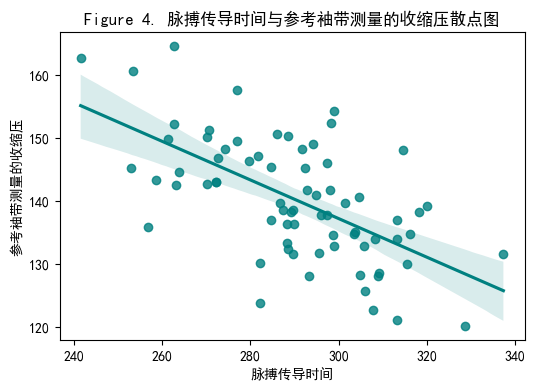

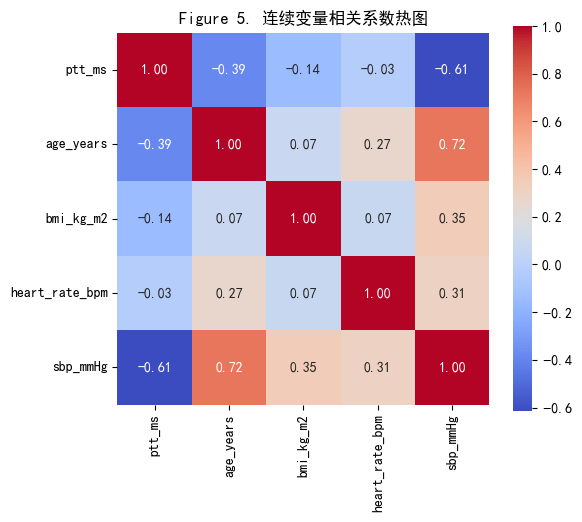

In [48]:
plt.figure(figsize=(6, 4))
sns.regplot(x="ptt_ms", y="sbp_mmHg", data=data2, color="teal")
plt.xlabel("脉搏传导时间")
plt.ylabel("参考袖带测量的收缩压")
plt.title("Figure 4. 脉搏传导时间与参考袖带测量的收缩压散点图")
plt.show()

plt.figure(figsize=(6, 5))
corr_matrix = data2[['ptt_ms', 'age_years', 'bmi_kg_m2', 'heart_rate_bpm', 'sbp_mmHg']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Figure 5. 连续变量相关系数热图")
plt.show()

这里我们按年龄分层，观察ptt和SBP的关系。
选取年龄的中位数44为分界点，分为高年龄组和低年龄组，绘制散点图与拟合曲线如下：

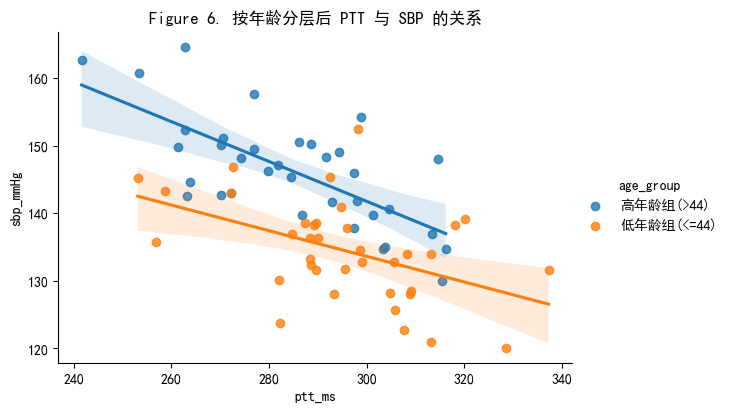

In [49]:
data2['age_group'] = np.where(data2['age_years'] > 44, '高年龄组(>44)', '低年龄组(<=44)')
sns.lmplot(x="ptt_ms", y="sbp_mmHg", hue="age_group", data=data2, height=4, aspect=1.5)
plt.title("Figure 6. 按年龄分层后 PTT 与 SBP 的关系")
plt.show()

### 3. 先建立未调整的简单线性模型：
`sbp_mmHg ~ ptt_ms`

记录 ptt_ms 的系数、p 值和 R-squared。(0.3 points)

In [50]:
model_simple = smf.ols('sbp_mmHg ~ ptt_ms', data=data2).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:               sbp_mmHg   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     42.52
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           9.24e-09
Time:                        16:47:59   Log-Likelihood:                -247.60
No. Observations:                  72   AIC:                             499.2
Df Residuals:                      70   BIC:                             503.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    229.3901     13.706     16.736      0.0

从上表可知：
- ptt_ms的系数：-0.3073
- p值：$9.24 \times 10^{-9}$
- R_Squared：0.378

### 4.建立多元线性模型：
`sbp_mmHg ~ ptt_ms + age_years + bmi_kg_m2 + heart_rate_bpm`

写出数学模型公式，并说明每个回归系数的“在其他变量不变时”的解释。(0.3 points)

多元回归模型数学公式：

$$
Y_{\text{sbp}} = \beta_0 + \beta_1 X_{\text{ptt}} + \beta_2 X_{\text{age}} + \beta_3 X_{\text{bmi}} + \beta_4 X_{\text{hr}} + \varepsilon
$$

回归系数的“保持其他变量不变”的解释：
- $\beta_0$：所有变量为 0 时 $Y$ 的均值
- $\beta_1$：在受试者的年龄、BMI、心率保持不变的条件下，脉搏传导时间每增加 1 $ms$，收缩压平均改变 $\beta_1$
- $\beta_2$：在受试者的脉搏传导时间、BMI、心率保持不变的条件下，年龄每增加1岁，收缩压平均改变 $\beta_2$
- $\beta_3$：在受试者的脉搏传导时间、年龄、心率保持不变的条件下，BMI每增加 1 $kg/m^2$ ，收缩压平均改变 $\beta_3$
- $\beta_4$ ：在受试者的脉搏传导时间、年龄、BMI保持不变的条件下，心率每增加 1 $beats/min$ ，收缩压平均改变 $\beta_4$

In [51]:
model_multi = smf.ols('sbp_mmHg ~ ptt_ms + age_years + bmi_kg_m2 + heart_rate_bpm', data=data2).fit()
print("\n--- 多元线性模型报告 ---")
print(model_multi.summary())


--- 多元线性模型报告 ---
                            OLS Regression Results                            
Dep. Variable:               sbp_mmHg   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     46.99
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           9.27e-19
Time:                        16:47:59   Log-Likelihood:                -216.58
No. Observations:                  72   AIC:                             443.2
Df Residuals:                      67   BIC:                             454.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        143.2245 

### 5. 结合多元模型输出报告解释：每个系数、标准误、t 值、p 值、95% 置信区间、R-squared、Adj. R-squared、F-statistic、AIC/BIC。(0.3 points)

首先是多元线性模型的各个参数及统计量，具体含义见上一小问：

| 系数 | 系数值 | 标准误 | t值 | p值 | 95%置信区间
|:----------------:|:-----------:|:---------:|:---------:|:-------:|:-------:|
| $b_0$ | $143.2245 mmHg$ | 13.554 | 10.567 | 0.000 | [116.170, 170.279] |
| $b_1$ | $-0.1867 mmHg/ms$ | 0.034 | -5.435 | 0.000 | [-0.255, -0.118] |
| $b_2$ | $0.3797 mmHg/\text{岁}$ | 0.051 | 7.431 | 0.000 | [0.278, 0.482] |
| $b_3$ | $0.8032 (mmHg \cdot m^2)/kg$ | 0.207 | 3.876 | 0.000 | [0.390, 1.217] |
| $b_4$ | $0.2057 (mmHg \cdot min)/beats$ | 0.098 | 2.100 | 0.040 | [0.010, 0.401] |

- 其中 $b_0=143.22$ 表示自变量为0时因变量的均值

- 在控制了年龄、BMI 和心率后，脉搏传导时间对收缩压具有显著的独立负向预测作用（$b_1 = -0.19$, $t(67) = -5.44$, $p < .001$, $95\%\text{ CI } [-0.26, -0.12]$，不包含0）。

- 在控制了 PTT、BMI 和心率等混杂因素后，年龄对收缩压表现出极其显著的正向独立影响（$b_2 = 0.38$, $t(67) = 7.43$, $p < .001$, $95\%\text{ CI } [0.28, 0.48]$，不包含0）。

- 在排除其他自变量的协同干扰后，BMI也是收缩压显着且强烈的正向独立预测因子（$b_3 = 0.80$, $t(67) = 3.88$, $p < .001$, $95\%\text{ CI } [0.39, 1.22]$，不包含0）。

- 在保持模型中其他三项自变量恒定的条件下，心率对收缩压也具有统计学上显著的正向独立贡献（$b_4 = 0.21$, $t(67) = 2.10$, $p = .040<.05$, $95\%\text{ CI } [0.01, 0.40]$，不包含0）。


R-Squared：0.737，$R^2 = \frac{SSR}{SST}$，代表有73.7%的数据可以由模型解释，属于强相关，说明模型有一定的价值

Adj. R-Squared：0.722，$ R^2_{adj}=1-\frac{(1-R^2)(n-1)}{n-p-1} $，考虑变量数量后并进行惩罚，数值略有下降，说明模型选择变量效果还是较好的

F-statistic：46.99，零假设检验的F统计量，用于检验整个模型的显著性。这里得到的p值为 $ 9.27 \times 10^{-19} $，远远小于0.05，拒绝原假设，认为这四个变量联合预测收缩压的线性关系是显著的

AIC：443.2，赤池信息量准则；BIC：454.5，贝叶斯信息量准则。用于进行模型之间的对比评估





### 6. 比较未调整模型与多元模型中 `ptt_ms` 系数的变化。说明年龄、BMI、心率为什么可能是混杂因素，以及多元线性模型如何帮助控制混杂。(0.3 points)

未调整模型中ptt_ms的系数为： -0.3073 

多元模型中ptt_ms的系数为：-0.1867

可以看到与简单模型相比，多元模型的系数明显减小，说明存在混在因素；根据实际情况来看，年龄、BMI、心率也确实是混杂因素：年龄增长或者BMI升高，都会使血管弹性下降，一方面导致SBP升高，另一方面导致PTT缩短。如Figure. 5中所示， Age与SBP呈0.72的强正相关、与PTT 呈-0.39的负相关；

而多元线性模型通过将这些协变量纳入方程的变量，最终得到各个变量的独立贡献，控住了混杂因素的影响。

### 7. 检查模型诊断：残差-拟合值图、Q-Q 图、异常点或高影响点、同方差性、残差正态性。计算 VIF 评价多重共线性。(0.3 points)

In [52]:
X = model_multi.model.exog
vif_data = pd.DataFrame()
vif_data["feature"] = model_multi.model.exog_names
vif_data["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
print("多重共线性VIF指标如下：")
print(vif_data)

多重共线性VIF指标如下：
          feature         VIF
0       Intercept  512.814804
1          ptt_ms    1.203625
2       age_years    1.274053
3       bmi_kg_m2    1.025579
4  heart_rate_bpm    1.090169


- 截距：vif高达512.81，原因是没有对四个自变量进行中心化，不影响我们对模型的评价
- 四个自变量：vif分别为1.20、1.27、1.02、1.09，均在1附近，表明四个自变量之间无明显共线性，解释变量之间信息重复较少

### 8. 计算多元模型的 RMSE 和 MAE。说明该模型用于解释 PTT 与 SBP 关系时是否足够；如果要做临床级预测，还缺少哪些证据。(0.3 points)

参考上综合题一中已经给出的公式，这里直接用python程序进行计算：

In [53]:
residuals_multi = model_multi.resid
rmse_multi = np.sqrt(np.mean(residuals_multi**2))
mae_multi = np.mean(np.abs(residuals_multi))

print(f"多元模型的 RMSE 值为：{rmse_multi:.4f}")
print(f"多元模型的 MAE 值为：{mae_multi:.4f}")

多元模型的 RMSE 值为：4.8994
多元模型的 MAE 值为：3.8535


解释关系是否足够：目前该多元线性模型足以用于解释 PTT 与 SBP 之间的群体线性相关关系 。模型的 MAE 为 3.85 mmHg，说明预测误差的平均绝对水平相对较小；同时结合模型整体的 F 检验和各变量极显著的 p 值，证明这四个变量能有效解释 SBP 大部分方差的变化 。

临床预测还欠缺证据，仅列举一些方面：
- 个体精度不达标：虽然MAE看似接近部分临床标准，但国际通用标准要求大样本测试下平均误差在 $\pm 5$ mmHg 以内且标准差须 $<8$ mmHg 。我们当前的RMSE为4.90 mmHg偏高，暗示模型在个体层面存在较大波动的残差，不足以支撑精准的个体血压诊断。
- 样本量与异质性代表性不足：本模型仅基于72人的小样本数据建立 ，缺乏多中心、大跨度年龄段的泛化测试。
- 未纳入底层物理混杂因素：可穿戴 PPG 信号极易受到患者个体皮肤光电反射率、局部微血管密度以及日常运动的干扰 ，要达到临床级预测，还需要补充针对这些底层物理环境因素的校准算法证据。


### 9. 对一名新受试者进行估计：PTT = 255 ms，年龄 = 55 岁，BMI = 28.0 kg/m2，心率 = 76 bpm。给出预测 SBP、95% 均值置信区间和 95% 个体预测区间，并解释在医学测量中预测区间的意义。(0.3 points)

In [54]:
new_patient = pd.DataFrame({
    'ptt_ms': [255.0],
    'age_years': [55],
    'bmi_kg_m2': [28.0],
    'heart_rate_bpm': [76.0]
})

pred_res = model_multi.get_prediction(new_patient).summary_frame(alpha=0.05)

print(f"预测收缩压: {pred_res['mean'][0]:.2f} mmHg")
print(f"95% 均值置信区间: [{pred_res['mean_ci_lower'][0]:.2f}, {pred_res['mean_ci_upper'][0]:.2f}] mmHg")
print(f"95% 个体预测区间: [{pred_res['obs_ci_lower'][0]:.2f}, {pred_res['obs_ci_upper'][0]:.2f}] mmHg")

预测收缩压: 154.63 mmHg
95% 均值置信区间: [151.79, 157.47] mmHg
95% 个体预测区间: [144.10, 165.16] mmHg


医学意义：在临床医学测量中，个体预测区间的指导意义远大于均值置信区间。因为医生面对的是具体的某一位患者，而不是统计学上的群体均值。个体预测区间告诉医生，这位特定患者的真实血压有 95% 的概率落在这个范围内，如果该区间的上限已经突破了高血压红线，即使点预测值正常，医生也需要警惕其高血压风险。

### 10. 用 1 段话总结该模型的主要结论、适用范围和局限性。(0.3 points)

本研究通过多元线性回归模型证明：在成功控制了年龄、BMI 和心率等显著生理混杂因素后，脉搏传导时间PTT对收缩压SBP依然具有高度显著的独立负向预测作用（$b = -0.19, p < .001，CI[-0.255, -0.118]$）。

该模型的适用范围：与本研究样本人口统计学特征相符的人群中，且各生理指标均需在模型所覆盖的观测值范围内。

其局限性在于：未纳入个体皮肤光电特性的动态校准机制、缺乏运动抗干扰设计，导致个体层次的预测方差较大，表现为个体预测区间较宽（如第9问所示）及RMSE偏高（如第8问所示），目前尚无法满足严苛的国际血压计临床诊断标准，因此仅可作为可穿戴设备日常趋势监测的参考，暂不能替代传统袖带血压计进行独立的医疗决策。